### Imports
    

In [1]:
import os
from dotenv import load_dotenv
from langchain_anthropic import ChatAnthropic
from langchain_neo4j import Neo4jGraph
from neo4j import GraphDatabase
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, AIMessage
from typing import TypedDict, List, Annotated
import operator
import pandas as pd
from langsmith import Client
from langgraph.checkpoint.memory import MemorySaver
from prompts import psychology_guidelines, schema_docs, system_prompt, neo4j_cs
import json
from datetime import datetime
load_dotenv()
langsmith_client = Client()

### Connect to Neo4j and setup Anthropic


In [2]:
try:
    driver = GraphDatabase.driver(
        os.environ.get("NEO4J_URI"),
        auth=(os.environ.get("NEO4J_USERNAME"), os.environ.get("NEO4J_PASSWORD"))
    )

    driver.verify_connectivity()
    print("Neo4j connection successful")
    
    graph = Neo4jGraph(
        url=os.environ.get("NEO4J_URI"),
        username=os.environ.get("NEO4J_USERNAME"),
        password=os.environ.get("NEO4J_PASSWORD"),
        timeout=30  
    )
    try:
        CACHED_SCHEMA = graph.get_schema
        print("Schema cached successfully")
        print(f"Schema preview: {str(CACHED_SCHEMA)[:200]}...")
    except Exception as schema_error:
        print(f"Could not cache schema: {schema_error}")
        CACHED_SCHEMA = None

    llm = ChatAnthropic(
        model="claude-3-5-haiku-latest",
        temperature=0.3,
        anthropic_api_key=os.getenv("ANTHROPIC_API_KEY"),
        max_tokens=4000
    )
    
    print("LLM initialized successfully")

except Exception as e:
    print(f"Setup failed: {e}")
    raise

Neo4j connection successful
Schema cached successfully
Schema preview: Node properties:
event_record {event_severity: STRING, q_length: INTEGER, road_name: STRING, event_desc: STRING, event_id: STRING, road_type: STRING, created_timestamp: DATE_TIME, id: INTEGER, event_s...
LLM initialized successfully


### Tools setup


In [ ]:
@tool
def run_cypher_query(query: str) -> str:
    """Execute a Cypher query against the Neo4j database to retrieve road network data.
    
    Use this tool when you need to:
    - Find specific roads, intersections, or traffic data
    - search for past event details either by the link id or the event id
    - Query relationships between road segments
    - Get traffic incident information
    - Analyze road network connectivity
    - Search for alternative route
    - Searching for VMS (FOR THE DISTANCE PLEASE GET FROM vms_range_get output)
    
    Args:
        query: A valid Cypher query string
        
    Returns:
        Query results as a string (limited to 50 records)
    """
    try:
        with driver.session() as session:
            result = session.run(query)
            records = [dict(record) for record in result]
            return str(records[:50])
    except Exception as e:
        return f"Query error: {str(e)}"

@tool 
def get_schema() -> str:
    """
    Get the Neo4j database schema including all node labels, relationship types and properties
    Use this tool FIRST before running any Cypher queries to understand:
    - What node labels exist (e.g., Road, Intersection, TrafficIncident)
    - What relationship types are available (e.g., CONNECTS_TO, HAS_INCIDENT)
    - What properties each node/relationship has
    
    This ensures your Cypher queries use correct labels, properties, and relationships
    that actually exist in the database to avoid query errors.
    
    Returns:
        Complete database schema information
    """

    print("Retrieving Schema from NEO4J...")
    try:
        if CACHED_SCHEMA is not None:
            return str(CACHED_SCHEMA)
        else:
            schema_info = graph.get_schema
            return str(schema_info)
    except Exception as e:
        return f"Schema error: {str(e)}"

@tool 
def generate_response_plan(context: str) -> str:
    """
    Generates a response plan based on the incident context retrieved from the knowledge graph
    Input: context (string) - Comprehensive context including incident details, VMS data importantly the id,
    event with their respective plan and plan command history to provide context.
    Returns: the explicit JSON formatted response plan with actions and VMS commands not the summary.
    """
    
    print("Generating Response plan...")

    prompt = f"""
    You are an expert in traffic management specializing in creating response plans.
    Based on traffic incident information and psychological principles, generate a comprehensive response plan.
    
    Context: {context}
    USE ALL the VMS provided to ensure sufficient coverage
    {psychology_guidelines}
    
    RESPONSE PLAN FORMAT:
    Generate a response plan in the following JSON format:

    {{
        "plan_type": "Traffic Management Plan",
        "priority": "High/Medium/Low",
        "estimated_duration": "X minutes/hours",
        "traffic_management_actions": [
            {{
                "eqt_no": "VMS_EQUIPMENT_ID (from EQT_NO or EQT_EXT_ID)",
                "message_line_1": "Primary message (max 20 chars)",
                "message_line_2": "Secondary message (max 20 chars)",
                "display_duration": "X minutes",
                "distance": "distance from event in meters",
                "psychological_rationale": "Why this message is psychologically effective",
                "behavioral_goal": "Desired driver behavior",
                "urgency_level": "High/Medium/Low based on distance and severity",
                "reasoning": "Give your reasoning for all of the above, why this duration etc."
            }},
            
            {{
                "action": "Specific action to take",
                "location": "Where to implement",
                "resources_needed": "What resources are required",
                "timing": "When to implement"
            }}
        ],
        "messaging_strategy": {{
            "primary_emotion": "Urgency/Caution/Information",
            "cognitive_approach": "Simple/Clear/Direct",
            "behavioral_target": "Slow down/Merge/Avoid area"
        }},
        "emergency_response": {{
            "agencies_to_notify": [
                {{
                    "agency": "Police/Fire Services/Emergency Medical Services/Road Maintenance/Traffic Control",
                    "priority": "Immediate/High/Medium/Low",
                    "reason": "Specific reason for notification",
                    "contact_method": "Emergency dispatch/Direct call/Radio",
                    "resources_requested": "Number of units/personnel needed"
                }}
            ],
            "coordination_requirements": "How agencies should coordinate",
            "scene_management": "Who takes lead and scene control responsibilities"
        }},
        "justification": "Psychology-based explanation of messaging choices"
    }}
    
    RECOMMENDED ACTIONS GUIDELINES:
    1. Generate additional actions that could aid in controlling the event
    2. Provide a priority level to recommended event
    3. Give clear reasoning and thought behind each event
    4. State the required equipment and personnel to carry out said action
    5. Recommend at least 2 actions

    EMERGENCY RESPONSE AGENCY GUIDELINES:
    1. POLICE: Required for all accidents with injuries, traffic control, investigation
    2. FIRE SERVICES: Required for vehicle fires, fuel spills, extraction operations
    3. EMERGENCY MEDICAL SERVICES: Required for any injuries, medical emergencies
    4. ROAD MAINTENANCE: Required for debris cleanup, road surface damage, barrier repairs
    5. TRAFFIC CONTROL: Required for major incidents affecting multiple lanes or extended duration
    6. TOWING SERVICES: Required for vehicle removal, clearance operations
    
    PRIORITY LEVELS:
    - Immediate: Life-threatening situations, major blockages during rush hour
    - High: Injuries present, significant traffic impact, hazardous conditions
    - Medium: Property damage only, minor traffic disruption, routine cleanup
    - Low: Minor incidents, off-peak hours, minimal impact
    
    PSYCHOLOGICAL MESSAGING RULES:
    1. Use psychology guidelines above to craft messages
    2. Consider time of day (0800 = rush hour psychology)
    3. Match message urgency to distance from incident
    4. Use action-oriented language that triggers immediate response
    5. Avoid cognitive overload - keep messages simple and clear
    6. Consider emotional state of stressed commuters

    Generate practical VMS messages that will effectively influence driver behavior and prevent secondary accidents.
    """
    
    try:
        response = llm.invoke(prompt)
        print("Response plan generated. Awaiting Human Feedback")
        return response.content
    except Exception as e:
        return f"Error generating psychology-based response plan: {str(e)}"
    
@tool
def extract_event_data(event_description: str) -> str:
    """
    Extract structured event data from user input or event updates.
    
    Args:
        event_description: Description of the traffic event or incident
    
    Returns:
        JSON with structured event data for comparison
    """
    print("Extracting event data from query.")
    prompt = f"""
    Extract structured data from this traffic event description:
    CHECK THE ROAD TYPE AS THIS WILL HAVE SIGNIFICANT IMPACT ON THE PLAN
    MUST TAKE INTO CONSIDERATION OF THE ROAD TYPE
    EVENT DESCRIPTION: {event_description}
    
    Return the data in this JSON format:
    {{
        "event_id": "unique identifier if mentioned or generate one",
        "link_id": "road link ID if mentioned",
        "incident_type": "accident/breakdown/roadworks/weather/other",
        "severity": "high/medium/low",
        "blocked_lanes": ["list", "of", "blocked", "lanes"],
        "queue_length": "length in meters (number only)",
        "time": "time in HHMM format",
        "duration_minutes": "how long incident has been active (number only)",
        "location_description": "human readable location",
        "additional_hazards": ["list", "of", "any", "additional", "hazards"],
        "weather_conditions": "if mentioned",
        "traffic_volume": "high/medium/low if assessable from time/location"
        "road_type": "major_roads/motorways/other_major_roads/secondary_roads/local_connecting_roads/local_roads_high_importance/local_roads/local_roads_minor_importance/other_roads (taken from incident link)"
    }}
    
    If information is not provided, use null for that field.
    Extract only factual information from the description.
    """
    
    try:
        response = llm.invoke(prompt)
        return response.content
    except Exception as e:
        return f"Error extracting event data: {str(e)}"

@tool
def analyze_event_changes(event_id: str, event_data: str) -> str:
    """
    Analyze changes between current and previous event states to determine if a response plan update is needed.
    
    Args:
        event_data: Current event data including incident details, lane closures, queue lengths
    
    Returns:
        JSON with analysis of changes and recommendation on whether to update the response plan
    """
    previous_data = None
    print("Analysing changes in event.")
    
    try:
        check_query = """
        MATCH (e:event_record {event_id: $event_id})
        RETURN e.event_id AS event_id
        """

        with driver.session() as session:
            existing = session.run(check_query, event_id=event_id).single()

            if existing:
                print("This is an ongoing event. Analyzing changes now.")

                result = session.run(
                    """
                    MATCH (n)
                    WHERE n.event_id = $event_id
                    RETURN n
                    """,
                    event_id=event_id
                )

                previous_data = [dict(record["n"]) for record in result]
                print(previous_data)

            else:
                print("This is a new event. Proceed to generate new response plan.")
                previous_data = None


        prompt = f"""
        You are an expert traffic management analyst. Compare the current event data with previous data
        and determine if changes warrant updating the response plan.

        CURRENT EVENT DATA:
        {event_data}

        PREVIOUS EVENT DATA:
        {previous_data or "No previous data available - this is a new event."}

        ANALYSIS RULES:
        1. Lane Blockages: ANY change in lane closures = HIGH significance, update required
        2. Queue Length: >500m change = HIGH significance, 200-500m = MEDIUM, <200m = LOW  
        3. Incident Severity: ANY severity change = HIGH significance, update required
        4. Time Changes: >2 hours elapsed OR crossing rush hour periods = MEDIUM significance
        5. Additional Hazards: NEW hazards reported = HIGH significance, update required

        UPDATE DECISION LOGIC:
        - If ANY change has HIGH significance → update_required = TRUE
        - If 2+ changes have MEDIUM significance → update_required = TRUE  
        - If ALL changes are LOW significance → update_required = FALSE
        - If this is a new event (no previous data) → update_required = TRUE

        Return your analysis in the following JSON format:

        {{
            "event_id": "{event_id}",
            "is_update": {str(previous_data is not None).lower()},
            "update_required": true/false,
            "significant_changes": [
                {{
                    "metric": "lane_blockage/queue_length/severity/time/hazards",
                    "previous_value": "previous value if available",
                    "current_value": "current value",
                    "significance": "high/medium/low",
                    "reasoning": "Why this change matters or doesn't"
                }}
            ],
            "critical_changes": true/false,
            "recommendation": "Update response plan / No update needed",
            "explanation": "Detailed explanation based on the UPDATE DECISION LOGIC above"
        }}

        IMPORTANT: 
        - DO NOT return anything other than the JSON output 
        - NO additional explanations outside of JSON are require
        - Be strict about update_required - only set to TRUE if genuinely significant changes occurred
        - If no meaningful changes, set update_required = FALSE to avoid unnecessary plan generation
        - For new events (no previous data), always set update_required = TRUE
        """

        response = llm.invoke(prompt)
        return response.content

    except Exception as e:
        return f"Error analyzing event changes: {str(e)}"

    
@tool
def store_event_details(event_data: str, event_id: str, graph_schema: str = None) -> str:
    """
    Stores event details as an `event_record` node in Neo4j.

    Args:
        event_data: JSON string of structured event data.
        event_id: Unique identifier for the event.
        graph_schema: JSON string of the graph schema (optional, will use cached schema if not provided)

    Returns:
        Confirmation of storage with event ID.
    """
    try:
        print("Creating Event Record node in NEO4J now.")
        # Use provided schema or fall back to cached schema
        schema_to_use = graph_schema if graph_schema else str(CACHED_SCHEMA) if CACHED_SCHEMA else "Schema not available"
        
        prompt = f"""
        You are an expert in generating Neo4j Cypher queries.
        UTILIZE MERGE NOT CREATE FUNCTION WHEN UPDATING

        Use the schema below to:
        1. Create an `event_record` node.
        2. Use only the properties listed under the `event_record` node in the schema.
        3. Replace missing or unknown values with null.
        4. Add in additional property road_type taken from the incident link
        5. Use '{event_id}' as the event_id.
        6. Add a `created_timestamp` with datetime().
        7. End with: RETURN e.event_id AS event_id

        IMPORTANT RELATIONSHIP CREATION:
        - After creating the event_record, find the road link using the link_id from the event data
        - Create a CONNECTED_TO relationship: (event_record)-[:LOCATED_AT]->(road_link)
        - The road link should be matched by its link_id property (or similar identifier)

        SCHEMA: {schema_to_use}

        EVENT DATA:
        {event_data}

        Output ONLY a valid Cypher query. Do NOT include any explanation.
        """

        response = llm.invoke(prompt)

        with driver.session() as session:
            result = session.run(response.content)
            record = result.single()
            
            return f"Event stored successfully with ID: {record['event_id']}"


    except Exception as e:
        return f"Error storing event: {str(e)}" 


# Can edit the cypher to add more properties to plan node
@tool
def store_event_plan(response_plan: str, event_id: str, vms_used: list = None) -> str:
    """
    Stores a response plan as an `event_plan` node in Neo4j and links it to the corresponding `event_record`.

    Args:
        response_plan: JSON string of the plan details.
        event_id: ID of the associated event.
        vms_used: list of EQT_NO of the vms used in the plan (optional, will extract from plan if not provided)
        graph_schema: JSON string of the graph schema (optional, will use cached schema if not provided)

    Returns:
        Confirmation message with plan ID if available.
    """
    print("Creating Plan node in NEO4J now.")
    try:
        # Extract VMS IDs from response plan if not provided
        if not vms_used:
            try:
                print("VMS list not provided, extracting from plan now.")
                import json
                plan_data = json.loads(response_plan)
                vms_used = []
                
                # Extract from traffic_management_actions
                if 'traffic_management_actions' in plan_data:
                    for action in plan_data['traffic_management_actions']:
                        if 'eqt_no' in action and action['eqt_no']:
                            vms_used.append(action['eqt_no'])
                
                print(f"Extracted VMS IDs from plan: {vms_used}")
            except Exception as e:
                print(f"Could not extract VMS IDs from plan: {e}")
                vms_used = []

        # Create the main event_plan node first
        main_query = f"""
        MERGE (ep:event_plan {{event_id: '{event_id}'}})
        ON CREATE SET 
            ep.id = toString(randomUUID()),
            ep.created_timestamp = datetime(),
            ep.plan_status = 'active'
        SET ep.plan_details = $plan_data
        WITH ep
        MATCH (er:event_record {{event_id: '{event_id}'}})
        MERGE (er)-[:HAS_PLAN]->(ep)
        RETURN ep.id AS plan_id
        """

        with driver.session() as session:
            # Execute main query to create event_plan and link to event_record
            result = session.run(main_query, plan_data=response_plan)
            record = result.single()
            plan_id = record.get('plan_id', 'unknown') if record else 'unknown'
            
            # Create VMS relationships separately if VMS IDs exist
            vms_linked = 0
            if vms_used:
                for vms_id in vms_used:
                    try:
                        vms_query = """
                        MATCH (ep:event_plan {event_id: $event_id}), (vms:VMS {EQT_NO: $vms_id})
                        MERGE (vms)-[:CONTROLS_VMS]->(ep)
                        RETURN vms.EQT_NO AS linked_vms
                        """
                        vms_result = session.run(vms_query, event_id=event_id, vms_id=vms_id)
                        if vms_result.single():
                            vms_linked += 1
                            print(f"Successfully linked VMS {vms_id}")
                        else:
                            print(f"VMS {vms_id} not found in database")
                    except Exception as vms_error:
                        print(f"Error linking VMS {vms_id}: {vms_error}")
            
            return f"Response plan stored successfully with ID: {plan_id}. VMS linked: {vms_linked}/{len(vms_used)} devices"

    except Exception as e:
        print(f"Error details: {str(e)}")
        return f"Error storing plan: {str(e)}"

    
# Add the new tool to the tools list
tools = [get_schema, run_cypher_query, generate_response_plan, analyze_event_changes, extract_event_data, store_event_details, store_event_plan]
tool_node = ToolNode(tools)


### Parsing error handler

In [ ]:
def custom_parsing_error_handler(error):
    """Custom handler to see what the LLM actually outputs"""
    print("=" * 50)
    print("PARSING ERROR DETECTED!")
    print("Error message:", str(error))
    print("=" * 50)
    

    error_str = str(error)
    if "Could not parse LLM output:" in error_str:
        # Extract the actual output
        start_idx = error_str.find("Could not parse LLM output:") + len("Could not parse LLM output:")
        end_idx = error_str.find("For troubleshooting")
        if end_idx == -1:
            actual_output = error_str[start_idx:].strip()
        else:
            actual_output = error_str[start_idx:end_idx].strip()
        
        print("ACTUAL LLM OUTPUT:")
        print(actual_output)
        print("=" * 50)
        
        # Return a formatted response
        return f"LLM tried to use tool but format was wrong. Raw output: {actual_output}"
    
    return f"Parsing error: {error}"

### State definition

In [5]:
class GraphState(TypedDict):
    messages: Annotated[List[HumanMessage | AIMessage], operator.add]
    tool_calls: List[dict]
    user_feedback: str
    final_approved: bool
    revision_count: int
    needs_revision: bool
    current_plan: str
    event_history: List[dict]
    event_id: str
    previous_event_state: str
    current_event_state: str
    event_analysis_completed: bool
    update_required: bool
    approved_plan: bool
    response_plan_generated: bool
    event_stored: bool
    plan_stored: bool


### Workflow implementation

In [ ]:
def should_continue(state: GraphState):
    """Decide whether to continue with tools or end."""
    last_message = state["messages"][-1]
    needs_revision = state.get("needs_revision", False)
    final_approved = state.get("final_approved", False)
    event_stored = state.get("event_stored", False)
    plan_stored = state.get("plan_stored", False)
    event_analysis_completed = state.get("event_analysis_completed", False)
    update_required = state.get("update_required", None)

    # Check if storage operations are complete (only after human approval)
    for message in reversed(state["messages"][-20:]):  
        if hasattr(message, 'name') and message.name == "store_event_details":
            if hasattr(message, 'content') and "successfully" in message.content.lower():
                event_stored = True
                print("Event storage detected")
                break
    
    for message in reversed(state["messages"][-20:]):  
        if hasattr(message, 'name') and message.name == "store_event_plan":
            if hasattr(message, 'content') and "successfully" in message.content.lower():
                plan_stored = True
                print("Plan storage detected")
                break
    
    print(f"Storage status: event_stored={event_stored}, plan_stored={plan_stored}, final_approved={final_approved}")

    # If storage is complete, end the workflow
    if plan_stored and event_stored and final_approved:
        print("Storage completed successfully - ending workflow")
        return END
    
    # Check for event analysis completion and update_required
    for message in reversed(state["messages"][-15:]): 
        if (hasattr(message, 'name') and 
            message.name == "analyze_event_changes" and
            hasattr(message, 'content')):
            event_analysis_completed = True
            try:
                import json
                analysis_result = json.loads(message.content)
                update_required = analysis_result.get("update_required", True)
                print(f"Analysis result: update_required={update_required}")
            except Exception as e:
                print(f"Failed to parse analysis result: {e}")
                update_required = True
            break
        
    if not event_analysis_completed:
        print("Event not analyzed, continuing with tools")
        return "tools" 
    
    # If analysis says no update required, end
    if update_required == False:
        print("Event analysis complete: No response plan update required - ending workflow")
        return END
    
    # Handle revision cases
    if needs_revision:
        if hasattr(last_message, 'tool_calls') and last_message.tool_calls:
            return "tools"  
    
    if hasattr(last_message, 'tool_calls') and last_message.tool_calls:
        return "tools"
    
    if final_approved:
        print("Plan approved - continuing to storage")
        return "tools"
    

    response_plan_generated = False
    for message in reversed(state["messages"][-10:]):
        if (hasattr(message, 'name') and 
            message.name == "generate_response_plan" and
            hasattr(message, 'content')):
            response_plan_generated = True
            print("Response plan generated - routing to human review")
            return "human_feedback"
    
 
    if (hasattr(last_message, 'content') and 
        last_message.content and
        ("plan_type" in last_message.content or "traffic_management_actions" in last_message.content)):
        print("AI message contains response plan - routing to human review")
        return "human_feedback"
    
    if update_required == True and not response_plan_generated:
        print("Response plan not generated, continue workflow")
        return "tools"
    
    print("Default case - continuing with tools")
    return "tools"


def route_after_human_feedback(state: GraphState):
    """Route after human feedback"""
    final_approved = state.get("final_approved", False)
    user_feedback = state.get("user_feedback", "")
    
    print(f"Routing decision: approved={final_approved}, feedback='{user_feedback}'")
    
    if final_approved:
        print("Plan approved - routing back to agent to store in database")
        return "agent"  
    else:
        print("Feedback received - rerunning with improvements") 
        return "agent" 


def call_model(state: GraphState):
    """Call the LLM with the current state"""
    
    user_feedback = state.get("user_feedback", "")
    needs_revision = state.get("needs_revision", False)
    current_plan = state.get("current_plan", "")
    final_approved = state.get("final_approved", False)


    system_message = {"role": "system", "content": system_prompt}

    valid_messages = []
    for msg in state["messages"]:
        if hasattr(msg, 'content') and msg.content and str(msg.content).strip():
            valid_messages.append(msg)
        elif hasattr(msg, 'tool_calls') and msg.tool_calls:
            valid_messages.append(msg)
        else:
            print(f"Skipping empty message: {type(msg)}")
    
    messages = [system_message] + valid_messages
    
    if final_approved and current_plan:
        event_stored = False
        plan_stored = False
        
        for message in reversed(state["messages"][-30:]):
            if (hasattr(message, 'name') and message.name == "store_event_details" and 
                hasattr(message, 'content') and "successfully" in message.content.lower()):
                event_stored = True
            if (hasattr(message, 'name') and message.name == "store_event_plan" and
                hasattr(message, 'content') and "successfully" in message.content.lower()):
                plan_stored = True
        
        if not event_stored and not plan_stored:
            storage_prompt = """
            The response plan has been approved. Store the event details first using store_event_details tool.
            Extract the event_id and event data from previous messages.
            """
        elif event_stored and not plan_stored:
            storage_prompt = f"""
            Event details have been stored successfully. Now store the approved response plan using store_event_plan tool.
            
            APPROVED PLAN TO STORE:
            {current_plan}
            """
        else:
            # Both are done, shouldn't reach here
            storage_prompt = "Both event and plan have been stored successfully."
        
        storage_message = HumanMessage(content=storage_prompt)
        messages.append(storage_message)
        
        print(f"Storage instruction: event_stored={event_stored}, plan_stored={plan_stored}")
    
    elif needs_revision and user_feedback and user_feedback.lower() != "approve":
        revision_prompt = f"""
        HUMAN REVIEWER FEEDBACK: {user_feedback}
        CURRENT PLAN: {current_plan}
        
        The human reviewer has provided feedback on your response plan. 
        Please revise the plan based on this feedback while maintaining:
        1. All safety protocols
        2. Psychological messaging principles  
        3. Proper JSON format
        4. VMS equipment IDs from the database
        
        You can also use tools to search for more VMS if required
        Generate an improved response plan that addresses the reviewer's concerns.
        """
        
        feedback_message = HumanMessage(content=revision_prompt)
        messages.append(feedback_message)
        
        print(f"Adding human feedback to LLM: {user_feedback}")

    llm_with_tools = llm.bind_tools(tools)
    
    response = llm_with_tools.invoke(messages)
    
    return {
        "messages": [response],
        "needs_revision": False,  
        "user_feedback": "",
        "final_approved": final_approved,  
        "current_plan": current_plan 
    }

def human_feedback(state: GraphState):
    plan = "No plan found"
    for message in reversed(state["messages"]):
        if hasattr(message, 'name') and message.name == "generate_response_plan":
            plan = message.content
            break
    
    print("=" * 60)
    print("HUMAN REVIEW REQUIRED")
    print("=" * 60)
    print("Response Plan:")
    print(plan)
    print("=" * 60)
    print("Type 'approve' to accept or anything else to reject:")
    
    feedback = input("Your decision: ")

    if feedback.strip().lower() == "approve":
        return {
            "user_feedback": feedback,
            "final_approved": True,
            "needs_revision": False,
            "current_plan": plan
        }
    else:
        return {
            "user_feedback": feedback,
            "final_approved": False,
            "needs_revision": True,  
            "revision_count": state.get("revision_count", 0) + 1,
            "current_plan": plan
        }



workflow = StateGraph(GraphState)


workflow.add_node("agent", call_model)
workflow.add_node("tools", tool_node)
workflow.add_node("human_feedback", human_feedback)
workflow.set_entry_point("agent")

workflow.add_conditional_edges(
    "agent",
    should_continue,
    {
        "tools": "tools",
        "human_feedback": "human_feedback",
        END: END
    }
)

workflow.add_conditional_edges(
    "human_feedback",
    route_after_human_feedback,
    {
        "agent": "agent",  
        END: END         
    }
)

workflow.add_edge("tools", "agent")
memory = MemorySaver()
app = workflow.compile(checkpointer=memory)

### WorkFlow visualization

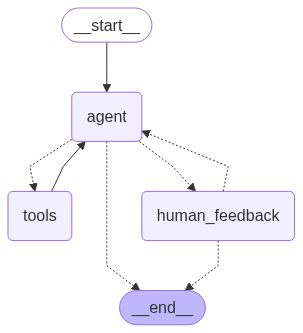

In [7]:
# Add this import at the top with your other imports
from IPython.display import Image, display


graph_image = app.get_graph().draw_mermaid_png()
    
    # Display the image
display(Image(graph_image))
    

### Initialize chatbot

In [17]:
class RoadNetworkChatBot:
    def __init__(self, verbose = True):
        self.app = app
        self.verbose = verbose
        self.schema = CACHED_SCHEMA

        if self.verbose:
            print("Initializing chatbot with cached schema...")
            if self.schema:
                print(f"Schema loaded: {str(self.schema)[:100]}...")
            else:
                print("No cached schema available")
    
    def get_cached_schema(self):
        """Get the cached schema without making a database call"""
        return str(self.schema) if self.schema else "Schema not available"
    
    def query(self, question: str, run_name: str = None):
        try:
            if self.verbose:
                print(f"Starting query: {question}")

            initial_state = {
                "messages": [HumanMessage(content=question)],
                "tool_calls": []
            }

            config = {
                "configurable": {"thread_id": "default"},  # Add this line
                "run_name": run_name or f"traffic_query_{len(question.split())}_words",
                "tags": ["traffic-management", "neo4j", "langgraph"],
                "metadata": {
                    "question_type": "traffic_incident" if "incident" in question.lower() else "general",
                    "question_length": len(question),
                    "timestamp": str(pd.Timestamp.now())
                },
                'recursion_limit':50
            }

            result = self.app.invoke(initial_state, config = config)
            
            if result and "messages" in result and result["messages"]:
                final_message = result["messages"][-1]
                if hasattr(final_message, 'content'):
                    return final_message.content
                else:
                    return str(final_message)
            else:
                return "No response generated"
            
        except Exception as e:
            if self.verbose:
                print(f"Error occurred: {e}")
            return f"Error: {e}"
    
    def stream_query(self, question: str, run_name: str = None):
        """Stream the response for real-time updates."""
        initial_state = {
            "messages": [HumanMessage(content=question)],
            "tool_calls": []
        }

        config = {
            "configurable": {"thread_id": "stream"}, 
            "run_name": run_name or f"stream_traffic_query",
            "tags": ["traffic-management", "streaming", "neo4j"],
            "metadata": {"streaming": True},
            'recursion_limit':50
        }
        
        for chunk in self.app.stream(initial_state, config = config):
            if self.verbose:
                print(f"Chunk received: {list(chunk.keys())}")
            yield chunk



### Tests

In [ ]:
chatbot = RoadNetworkChatBot()
incident_query = "The event_id is 38382929, At 12:45 this morning, a multi-vehicle accident occurred on road link 17840006094278 near the junction with Elmwood Avenue Motorway. Two lanes are currently blocked, causing a queue of approximately 3000 meters. Emergency services are on site, and the incident has been active for 35 minutes. The severity is high due to the number of vehicles involved and the impact on traffic flow. Additional hazards include spilled fuel and debris on the road. Weather conditions are foggy, contributing to low visibility. Traffic volume is high due to rush hour."
result = chatbot.query(incident_query)
print(result)


Initializing chatbot with cached schema...
Schema loaded: Node properties:
event_record {id: INTEGER, event_sub_type_id: FLOAT, on_scene_time: FLOAT, event_se...
Starting query: the event_id is 38382929, At 12:45 this morning, a multi-vehicle accident occurred on road link 17840006094278 near the junction with Elmwood Avenue Motorway. Two lanes are currently blocked, causing a queue of approximately 3000 meters. Emergency services are on site, and the incident has been active for 35 minutes. The severity is high due to the number of vehicles involved and the impact on traffic flow. Additional hazards include spilled fuel and debris on the road. Weather conditions are foggy, contributing to low visibility. Traffic volume is high due to rush hour.
Storage status: event_stored=False, plan_stored=False, final_approved=False
Event not analyzed, continuing with tools
Retrieving Schema from NEO4J...
Storage status: event_stored=False, plan_stored=False, final_approved=False
Event not analyzed

Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.FeatureDeprecationWarning} {category: DEPRECATION} {title: This feature is deprecated and will be removed in future versions.} {description: The query used a deprecated function: `id`.} {position: line: 2, column: 14, offset: 29} for query: "MATCH (vms:VMS)\nWITH collect(id(vms)) AS targetNodes\n\nMATCH (incident:Link {link_id: '17840006094278'})\nCALL gds.shortestPath.dijkstra.stream('linkGraph', {\nsourceNode: incident,\ntargetNodes: targetNodes,\nrelationshipWeightProperty: 'weight'\n})\nYIELD targetNode, totalCost, nodeIds\n\nWITH gds.util.asNode(targetNode) AS vms, totalCost AS distance_meters, size(nodeIds) AS hops_from_incident\nWHERE distance_meters <= 8000\nRETURN \nvms.EQT_NO, \nvms.ROAD_NAME, \nvms.EQT_EXT_ID, \nvms.LINK_ID AS vms_link_id, \ndistance_meters, \nhops_from_incident\nORDER BY distance_meters ASC\nLIMIT 5"


Storage status: event_stored=False, plan_stored=False, final_approved=False
Analysis result: update_required=True


Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.FeatureDeprecationWarning} {category: DEPRECATION} {title: This feature is deprecated and will be removed in future versions.} {description: The query used a deprecated field from a procedure. ('schema' returned by 'gds.graph.drop' is deprecated.)} {position: line: 1, column: 1, offset: 0} for query: "CALL gds.graph.drop('linkGraph')"


Storage status: event_stored=False, plan_stored=False, final_approved=False
Analysis result: update_required=True
Storage status: event_stored=False, plan_stored=False, final_approved=False
Analysis result: update_required=True
Generating Response plan...
Response plan generated. Awaiting Human Feedback
Storage status: event_stored=False, plan_stored=False, final_approved=False
Analysis result: update_required=True
Response plan generated - routing to human review
HUMAN REVIEW REQUIRED
Response Plan:
Based on the comprehensive guidelines and incident details, here's a detailed Traffic Management Response Plan:

{
    "plan_type": "Traffic Management Plan",
    "priority": "High",
    "estimated_duration": "120 minutes",
    "traffic_management_actions": [
        {
            "eqt_no": "E11DMSG04S",
            "message_line_1": "MAJOR ACCIDENT",
            "message_line_2": "SLOW DOWN AHEAD",
            "display_duration": 45,
            "distance": 86,
            "psychological_

In [10]:
# chatbot = RoadNetworkChatBot()
# incident_query = "ONLY STORE EVENT DETAILS OF THIS EVENT TO THE DATABASE, DO NOT NEED RESPONSE PLAN. the event_id is 38382929, At 08:45 this morning, a multi-vehicle accident occurred on road link 17840006094278 near the junction with Elmwood Avenue. Two lanes are currently blocked, causing a queue of approximately 750 meters. Emergency services are on site, and the incident has been active for 35 minutes. The severity is high due to the number of vehicles involved and the impact on traffic flow. Additional hazards include spilled fuel and debris on the road. Weather conditions are foggy, contributing to low visibility. Traffic volume is high due to rush hour."
# result = chatbot.query(incident_query)
# print(result)

### To abort langsmith runs

In [5]:
from langsmith import Client
client = Client()
# run id of langsmith
run_id = "c31c1778-335f-40aa-b286-f90134e48a9b"

# Update the run status to "aborted" (equivalent to stopping it)
try:
	# First check if the run exists and its current status
	run_info = client.read_run(run_id=run_id)
	print(f"Current run status: {run_info.status}")
	
	# Only update if the run is not already finished
	if run_info.status not in ["success", "error", "cancelled"]:
		client.update_run(run_id=run_id, status="cancelled")
		print("Run successfully cancelled")
	else:
		print(f"Run is already finished with status: {run_info.status}")
		
except Exception as e:
	print(f"Error updating run: {e}")
	# If the run doesn't exist or can't be updated, that's okay
	if "404" in str(e):
		print("Run not found - it may have already been deleted")
	elif "409" in str(e):
		print("Run already completed - cannot update status")

Current run status: pending
Run successfully cancelled


In [12]:


# def test_with_streaming_human_loop(question):
#     print("=" * 60)
#     print(f"STREAMING TEST WITH HUMAN REVIEW: {question}")
#     print("=" * 60)
    
#     for chunk in chatbot.stream_query(question):
#         for node, output in chunk.items():
#             print(f"\nNode: {node}")
#             if "messages" in output:
#                 for msg in output["messages"]:
#                     if hasattr(msg, 'content'):
#                         # Truncate very long content for readability
#                         content = msg.content
#                         if hasattr(msg, 'type') and msg.type == 'ai':
#                             print(f"AI Thought Process:")
#                             print(f"{content}")
#                         else:
#                             print(f"Content: {content}")
#                     if hasattr(msg, 'tool_calls') and msg.tool_calls:
#                         print(f"Tool calls: {[tc.get('name', 'unknown') for tc in msg.tool_calls]}")

#                         for i, tool_call in enumerate(msg.tool_calls):
#                             tool_name = tool_call.get('name', 'unknown')
#                             tool_args = tool_call.get('args', {})
#                             print(f"   Tool {i+1}: {tool_name}")
#                             if tool_name == 'run_cypher_query':
#                                 query = tool_args.get('query', '')
#                                 print(f"   Query: {query}")
#                             elif tool_name == 'generate_response_plan':
#                                 context = tool_args.get('context', '')
#                                 print(f"   Context length: {len(context)} characters")

#             if node == "tools" and "messages" in output:
#                 for msg in output["messages"]:
#                     if hasattr(msg, 'content') and hasattr(msg, 'name'):
#                         tool_name = msg.name
#                         result = msg.content
#                         print(f"Tool '{tool_name}' executed:")
#                         print(f"Result: {result}")
            
#             # Show human feedback if present
#             if "human_feedback" in output:
#                 print(f"Human Feedback: {output['human_feedback']}")
#             if "final_approved" in output:
#                 print(f"Final Approval: {output['final_approved']}")

# # Update the test to use the new function
# print("\n" + "="*80)
# print("TESTING WORKFLOW WITH HUMAN-IN-THE-LOOP")
# print("="*80)

# # Initialize chatbot
# chatbot = RoadNetworkChatBot(verbose=True)

# # Test with human review
# test_with_streaming_human_loop("A car accident has occurred at link_id 17840006094278, the time is 0800, the event severity is medium, the event type is accident")
# # Run tests with tracking
# # for query in test_queries_list:
# #     test_and_track_query(chatbot, query)

# # # Print summary
# # print(f"\nTotal tests run: {len(test_queries)}")
# # print(f"Successful tests: {sum(1 for t in test_queries if t['success'])}")
# # print(f"Average duration: {sum(t['duration'] for t in test_queries) / len(test_queries):.2f}s")


## ToDo

1. Utilise GDS to use Dijkstras algorithim to search for VMS based on distance, Remember every GDS projection is static, so need to project new graph before search and drop after search
2. Add information of the rule based system to the LLM so it can find enough VMS, ie the different zones
3. Proper file structure
